In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.linear_model import LinearRegression, LogisticRegression

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)


## 2.1 理论计算题

### 1. 非线性激活函数的重要性

**证明过程：**

给定一个具有单隐藏层的多层感知机：
- 隐藏层（无激活函数）：$\mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$
- 输出层：$\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2$

将隐藏层表达式代入输出层：

$$\mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2$$

展开得：

$$\mathbf{o} = \mathbf{W}_2\mathbf{W}_1\mathbf{x} + \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$$

令：
- $\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$
- $\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$

则网络等价于单层神经网络：

$$\mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}'$$

**结论：** 没有非线性激活函数的多层线性网络本质上等价于单层线性网络，无法学习非线性特征，无法逼近非线性函数。这正是非线性激活函数在深度学习中至关重要的原因。

---

### 2. 激活函数性质分析

#### Sigmoid函数

**数学表达式：**
$$\sigma(x) = \frac{1}{1 + e^{-x}} = \frac{e^x}{1 + e^x}$$

**导数推导：**

$$\sigma'(x) = \frac{d}{dx}(1 + e^{-x})^{-1}$$

$$= -(1 + e^{-x})^{-2} \cdot (-e^{-x})$$

$$= \frac{e^{-x}}{(1 + e^{-x})^2}$$

$$= \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}}$$

$$= \sigma(x) \cdot (1 - \sigma(x))$$

**关系式：**
$$\sigma'(x) = \sigma(x)(1 - \sigma(x))$$

---

#### tanh函数

**数学表达式：**
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} = \frac{e^{2x} - 1}{e^{2x} + 1}$$

**导数推导：**

$$\tanh'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2}$$

$$= 1 - \left(\frac{e^x - e^{-x}}{e^x + e^{-x}}\right)^2$$

$$= 1 - \tanh^2(x)$$

**关系式：**
$$\tanh'(x) = 1 - \tanh^2(x)$$

In [2]:
#2.2 多层感知机从零实现"

# 加载Fashion-MNIST
def load_fashion_mnist(batch_size=256):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])
    train_dataset = datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )
    return DataLoader(train_dataset, batch_size, shuffle=True), \
           DataLoader(test_dataset, batch_size, shuffle=False)

# ReLU激活函数
def relu(x):
    return torch.maximum(torch.tensor(0.0), x)

# Softmax
def softmax(x):
    x_max = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - x_max)
    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

# 交叉熵损失
class CrossEntropyLoss:
    def __call__(self, logits, y):
        batch_size = logits.shape[0]
        probs = softmax(logits)
        log_probs = torch.log(probs + 1e-8)
        return -torch.sum(log_probs[range(batch_size), y]) / batch_size

# MLP从零实现
class MLPFromScratch:
    def __init__(self, input_size=784, hidden_size=256, num_classes=10):
        self.W1 = torch.randn(input_size, hidden_size) * 0.01
        self.b1 = torch.zeros(hidden_size)
        self.W2 = torch.randn(hidden_size, num_classes) * 0.01
        self.b2 = torch.zeros(num_classes)
        
    def forward(self, X):
        self.hidden = relu(torch.matmul(X, self.W1) + self.b1)
        self.logits = torch.matmul(self.hidden, self.W2) + self.b2
        return self.logits
    
    def backward(self, X, y):
        batch_size = X.shape[0]
        probs = softmax(self.logits)
        d_logits = probs.clone()
        d_logits[range(batch_size), y] -= 1
        d_logits /= batch_size
        
        self.grad_W2 = torch.matmul(self.hidden.T, d_logits)
        self.grad_b2 = torch.sum(d_logits, dim=0)
        
        d_hidden = torch.matmul(d_logits, self.W2.T)
        d_hidden[self.hidden <= 0] = 0
        self.grad_W1 = torch.matmul(X.T, d_hidden)
        self.grad_b1 = torch.sum(d_hidden, dim=0)
    
    def update(self, lr):
        self.W1 -= lr * self.grad_W1
        self.b1 -= lr * self.grad_b1
        self.W2 -= lr * self.grad_W2
        self.b2 -= lr * self.grad_b2

# 训练
train_loader, test_loader = load_fashion_mnist()
model = MLPFromScratch()
loss_fn = CrossEntropyLoss()

print("开始训练...")
for epoch in range(10):
    total_loss, correct, total = 0, 0, 0
    for X, y in train_loader:
        logits = model.forward(X)
        loss = loss_fn(logits, y)
        model.backward(X, y)
        model.update(0.1)
        total_loss += loss.item()
        correct += torch.sum(torch.argmax(logits, dim=1) == y).item()
        total += len(y)
    
    # 测试
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for X, y in test_loader:
            logits = model.forward(X)
            test_correct += torch.sum(torch.argmax(logits, dim=1) == y).item()
            test_total += len(y)
    
    print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}, "
          f"Train Acc={correct/total:.4f}, Test Acc={test_correct/test_total:.4f}")

print("MLP从零实现完成！")

100%|██████████| 26.4M/26.4M [22:49<00:00, 19.3kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 67.5kB/s]
100%|██████████| 4.42M/4.42M [04:52<00:00, 15.1kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 37.1kB/s]


开始训练...
Epoch 1: Loss=1.0444, Train Acc=0.6388, Test Acc=0.7243
Epoch 2: Loss=0.5976, Train Acc=0.7907, Test Acc=0.8104
Epoch 3: Loss=0.5236, Train Acc=0.8172, Test Acc=0.8115
Epoch 4: Loss=0.4830, Train Acc=0.8319, Test Acc=0.8270
Epoch 5: Loss=0.4546, Train Acc=0.8387, Test Acc=0.7963
Epoch 6: Loss=0.4360, Train Acc=0.8460, Test Acc=0.8256
Epoch 7: Loss=0.4165, Train Acc=0.8545, Test Acc=0.8362
Epoch 8: Loss=0.4071, Train Acc=0.8564, Test Acc=0.8353
Epoch 9: Loss=0.3927, Train Acc=0.8624, Test Acc=0.8491
Epoch 10: Loss=0.3842, Train Acc=0.8640, Test Acc=0.8356
MLP从零实现完成！


## 3.1 理论计算题

### 1. 过拟合与欠拟合

#### 训练误差与泛化误差的区别

| 概念 | 定义 | 特点 |
|------|------|------|
| **训练误差** | 模型在训练数据集上的误差 | 反映模型对训练数据的拟合程度 |
| **泛化误差** | 模型在未见过的测试数据上的期望误差 | 反映模型的真实预测能力 |

#### 过拟合状态

当一个模型的**训练误差极低，但泛化误差很高**时，模型处于**过拟合**状态。

**过拟合的特征：**
- 模型过度记忆了训练数据中的噪声和异常点
- 模型复杂度相对于数据量过高
- 泛化能力差，在新数据上表现不佳

#### 通过控制模型复杂度缓解过拟合

1. **减少模型规模**
   - 减少隐藏层数量
   - 减少每层神经元数量

2. **正则化技术**
   - L1正则化（Lasso）：产生稀疏权重
   - L2正则化（Ridge）：限制权重大小

3. **早停法（Early Stopping）**
   - 监控验证集误差，在开始上升时停止训练

4. **Dropout**
   - 随机丢弃部分神经元，防止协同适应

5. **数据增强**
   - 增加训练数据量或进行数据变换

---

### 2. K折交叉验证

#### 算法步骤

**输入：** 数据集 $D$，折数 $K$，学习算法 $A$

**步骤：**

1. **数据划分**
   - 将数据集 $D$ 随机打乱
   - 均匀分成 $K$ 个大小相等（或近似相等）的子集 $D_1, D_2, ..., D_K$

2. **循环验证**（对 $i = 1$ 到 $K$）
   - 令验证集 $Val_i = D_i$
   - 令训练集 $Train_i = D \setminus D_i$（除 $D_i$ 外的所有数据）
   - 在 $Train_i$ 上训练模型，得到模型 $M_i$
   - 在 $Val_i$ 上评估模型 $M_i$，记录性能指标 $score_i$

3. **计算平均性能**
   $$Score_{avg} = \frac{1}{K}\sum_{i=1}^{K} score_i$$


--- 无正则化 ---
Epoch 10: Train Loss=1.3239, Test Loss=1.2878
Epoch 20: Train Loss=0.8558, Test Loss=0.9225
Epoch 30: Train Loss=0.6738, Test Loss=0.7955
Epoch 40: Train Loss=0.5535, Test Loss=0.7239
Epoch 50: Train Loss=0.4734, Test Loss=0.7067

--- L2正则化 ---
Epoch 10: Train Loss=1.3239, Test Loss=1.2927
Epoch 20: Train Loss=0.8777, Test Loss=0.9210
Epoch 30: Train Loss=0.6831, Test Loss=0.8063
Epoch 40: Train Loss=0.5783, Test Loss=0.7253
Epoch 50: Train Loss=0.5017, Test Loss=0.7088

--- Dropout ---
Epoch 10: Train Loss=1.6131, Test Loss=1.5634
Epoch 20: Train Loss=1.0862, Test Loss=1.0710
Epoch 30: Train Loss=0.8697, Test Loss=0.8943
Epoch 40: Train Loss=0.7531, Test Loss=0.8077
Epoch 50: Train Loss=0.6503, Test Loss=0.7636


C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\2141027103.py:111: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\2141027103.py:111: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\2141027103.py:111: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\2141027103.py:111: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\2141027103.py:112: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  plt.savefig('regularization_comparison.png')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\21410271

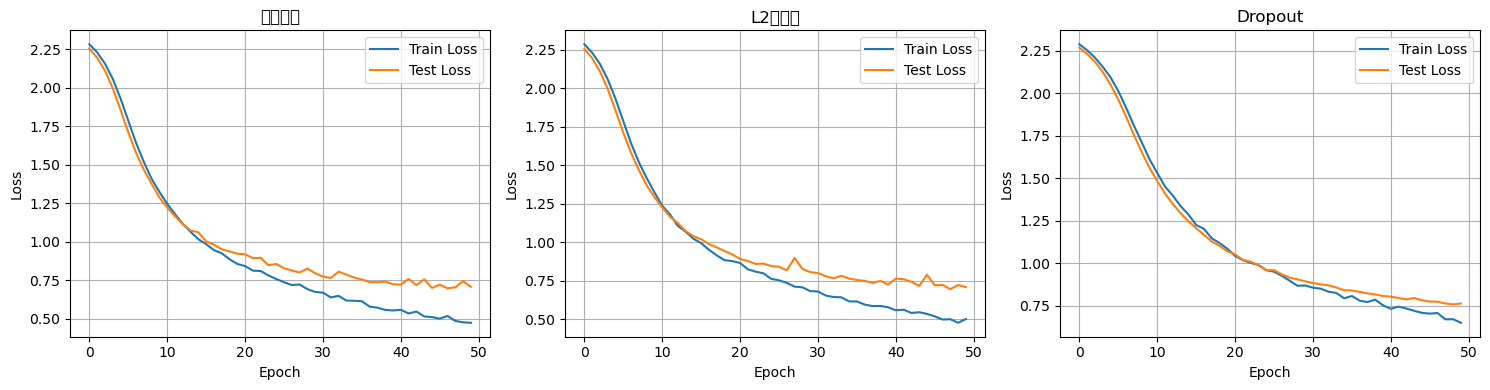

正则化对比实验完成！


In [3]:
#"3.2 L2正则化和Dropout实现"

# Dropout实现
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return X * mask / (1 - dropout)

# 带正则化的MLP
class MLPWithReg:
    def __init__(self, input_size=784, hidden_size=512, num_classes=10,
                 l2_lambda=0.0, dropout_rate=0.0):
        self.W1 = torch.randn(input_size, hidden_size) * 0.01
        self.b1 = torch.zeros(hidden_size)
        self.W2 = torch.randn(hidden_size, num_classes) * 0.01
        self.b2 = torch.zeros(num_classes)
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate
        self.training = True
        
    def forward(self, X):
        hidden = relu(torch.matmul(X, self.W1) + self.b1)
        if self.training and self.dropout_rate > 0:
            hidden = dropout_layer(hidden, self.dropout_rate, True)
        self.hidden = hidden
        self.logits = torch.matmul(hidden, self.W2) + self.b2
        return self.logits
    
    def backward(self, X, y):
        batch_size = X.shape[0]
        probs = softmax(self.logits)
        d_logits = probs.clone()
        d_logits[range(batch_size), y] -= 1
        d_logits /= batch_size
        
        self.grad_W2 = torch.matmul(self.hidden.T, d_logits) + self.l2_lambda * self.W2
        self.grad_b2 = torch.sum(d_logits, dim=0)
        
        d_hidden = torch.matmul(d_logits, self.W2.T)
        d_hidden[self.hidden <= 0] = 0
        self.grad_W1 = torch.matmul(X.T, d_hidden) + self.l2_lambda * self.W1
        self.grad_b1 = torch.sum(d_hidden, dim=0)
    
    def update(self, lr):
        self.W1 -= lr * self.grad_W1
        self.b1 -= lr * self.grad_b1
        self.W2 -= lr * self.grad_W2
        self.b2 -= lr * self.grad_b2
    
    def train(self): self.training = True
    def eval(self): self.training = False

# 使用少量样本创建过拟合场景
train_subset = torch.utils.data.Subset(
    datasets.FashionMNIST('./data', train=True, download=True,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Lambda(lambda x: x.view(-1))])),
    range(500)
)
train_loader_overfit = DataLoader(train_subset, batch_size=64, shuffle=True)

def train_with_reg(model, epochs=50, lr=0.05):
    loss_fn = CrossEntropyLoss()
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X, y in train_loader_overfit:
            logits = model.forward(X)
            loss = loss_fn(logits, y)
            model.backward(X, y)
            model.update(lr)
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader_overfit))
        
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for X, y in test_loader:
                logits = model.forward(X)
                test_loss += loss_fn(logits, y).item()
        test_losses.append(test_loss / len(test_loader))
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Test Loss={test_losses[-1]:.4f}")
    return train_losses, test_losses

# 对比实验
configs = [
    ("无正则化", MLPWithReg(l2_lambda=0.0, dropout_rate=0.0)),
    ("L2正则化", MLPWithReg(l2_lambda=0.001, dropout_rate=0.0)),
    ("Dropout", MLPWithReg(l2_lambda=0.0, dropout_rate=0.5))
]

results = {}
for name, model in configs:
    print(f"\n--- {name} ---")
    results[name] = train_with_reg(model)

# 绘图
plt.figure(figsize=(15, 4))
for i, (name, (train_loss, test_loss)) in enumerate(results.items()):
    plt.subplot(1, 3, i+1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(name)
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.savefig('regularization_comparison.png')
plt.show()
print("正则化对比实验完成！")

## 4.1 理论计算题

### 1. 梯度消失与梯度爆炸

#### 量化分析

考虑一个 $d$ 层的深层神经网络，梯度反向传播时包含多层矩阵连乘：

$$\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i} = \prod_{i=t}^{d-1} \text{diag}(\sigma'(h^i)) \mathbf{W}_i$$

其中：
- $\mathbf{W}_i$ 是第 $i$ 层的权重矩阵
- $\sigma'(\cdot)$ 是激活函数的导数

#### 梯度爆炸的条件

**发生条件：**
- 当权重矩阵的范数 $\|\mathbf{W}_i\| > 1$，且激活函数导数接近1时
- 连乘结果随层数增加指数级增长

**具体量化：**
- 若 $\|\mathbf{W}_i\| \approx \alpha > 1$，且 $\sigma'(\cdot) \approx 1$
- 则经过 $L$ 层后，梯度放大 $\alpha^L$ 倍
- 当 $L$ 较大时，$\alpha^L \to \infty$，导致梯度爆炸

**典型场景：**
- 权重初始化值过大
- 使用线性激活函数（导数恒为1）

#### 梯度消失的条件

**发生条件：**
- 当权重矩阵的范数 $\|\mathbf{W}_i\| < 1$，或激活函数导数 $\sigma'(\cdot) \ll 1$
- 连乘结果随层数增加指数级衰减

**具体量化：**
- 若 $\|\mathbf{W}_i\| \approx \beta < 1$，或 $\sigma'(\cdot) \approx 0.25$（Sigmoid最大导数）
- 则经过 $L$ 层后，梯度衰减 $\beta^L$ 倍或 $(0.25)^L$ 倍
- 当 $L$ 较大时，梯度趋近于0

**典型场景：**
- 使用Sigmoid或tanh激活函数（饱和区导数接近0）
- 权重初始化值过小

#### 梯度爆炸与消失的对比

| 现象 | 梯度爆炸 | 梯度消失 |
|------|---------|---------|
| 梯度变化 | 指数级增大 | 指数级衰减 |
| 浅层影响 | 参数更新过大，不稳定 | 参数几乎不更新 |
| 训练表现 | Loss变成NaN，无法收敛 | 训练极慢，浅层无法学习 |
| 权重条件 | $\|\mathbf{W}\| > 1$ | $\|\mathbf{W}\| < 1$ |
| 激活函数 | 导数接近1 | 导数远小于1 |

---

### 2. ReLU缓解梯度消失的原因

#### ReLU函数定义

$$\text{ReLU}(x) = \max(0, x) = \begin{cases} x, & x > 0 \\ 0, & x \leq 0 \end{cases}$$

#### ReLU的导数

$$\text{ReLU}'(x) = \begin{cases} 1, & x > 0 \\ 0, & x \leq 0 \end{cases}$$

#### 缓解梯度消失的原因

1. **导数恒为1（正值区域）**
   - 当输入 $x > 0$ 时，ReLU的导数为1
   - 不会像Sigmoid/tanh那样将梯度衰减到很小
   - 梯度可以完整地传播到浅层网络

2. **无饱和区**
   - Sigmoid在两端饱和，导数趋近于0
   - tanh也在两端饱和
   - ReLU只有负半轴饱和，正半轴无饱和问题

3. **稀疏激活**
   - 负半轴输出为0，产生稀疏性
   - 只有部分神经元被激活
   - 减少了梯度计算量，也缓解了梯度相互干扰

4. **计算简单**
   - 不需要指数运算
   - 前向和反向传播都很快

#### 对比分析

| 激活函数 | 导数范围 | 饱和区 | 梯度消失风险 |
|---------|---------|--------|-------------|
| Sigmoid | (0, 0.25] | 两端 | **高** |
| tanh | (0, 1] | 两端 | **较高** |
| ReLU | {0, 1} | 负半轴 | **低** |

#### 注意事项

ReLU也存在缺点：
- **神经元死亡**：当输入恒为负时，神经元永远输出0，梯度为0，无法恢复
- **解决方案**：使用Leaky ReLU、PReLU、ELU等变体

$$ \text{LeakyReLU}(x) = \begin{cases} x, & x > 0 \\ \alpha x, & x \leq 0 \end{cases} \quad (\alpha \text{通常取 } 0.01) $$


实验1: Sigmoid + 标准初始化
前3层梯度范数: [181.67095947265625, 92.55272674560547, 75.20574188232422]
后3层梯度范数: [4.026321887969971, 4.61328125, 5.874727249145508]
观察: 前层梯度远小于后层 → 梯度消失

实验2: ReLU + 大初始化 (std=10)
最大梯度范数: nan

实验3: Xavier初始化 + ReLU
梯度范数范围: [2.59e-03, 5.33e-03]
梯度稳定在合理区间

实验4: Xavier初始化 + LeakyReLU
梯度范数范围: [2.12e-03, 3.67e-03]


C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\4215789423.py:129: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\4215789423.py:129: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\4215789423.py:129: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\4215789423.py:129: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\4215789423.py:129: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\4215789423.py:129: UserWarning: Gl

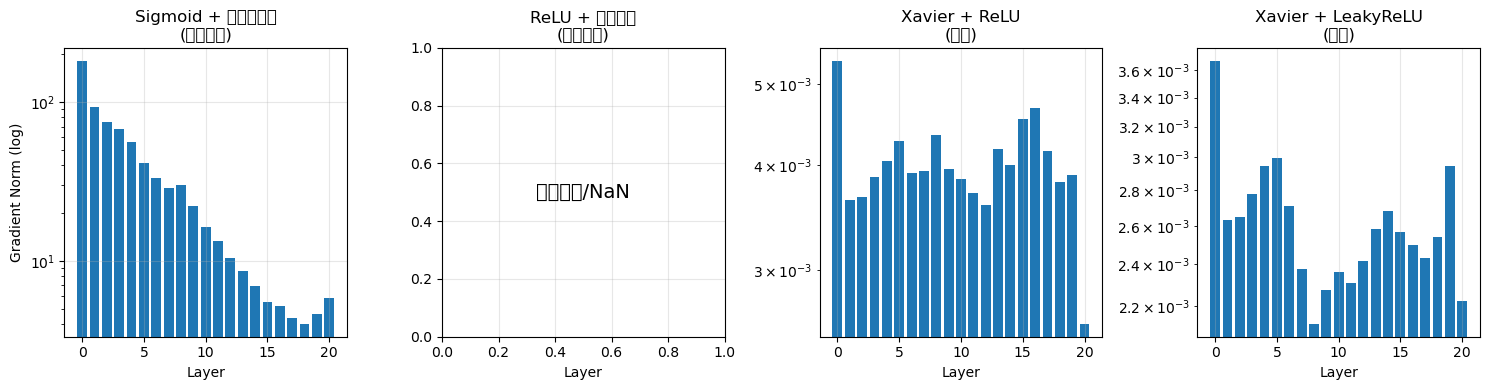


数值稳定性实验完成！


In [5]:
# 4.2 数值稳定性实验


import torch.nn.functional as F

class DeepNet(nn.Module):
    def __init__(self, num_layers=20, hidden_size=256, input_size=784, 
                 num_classes=10, activation='sigmoid'):
        super().__init__()
        layers = [nn.Linear(input_size, hidden_size)]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
        layers.append(nn.Linear(hidden_size, num_classes))
        self.layers = nn.ModuleList(layers)
        self.activation = activation
    
    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            if self.activation == 'sigmoid':
                x = torch.sigmoid(x)
            elif self.activation == 'relu':
                x = F.relu(x)
            elif self.activation == 'leaky_relu':
                x = F.leaky_relu(x, 0.01)
        return self.layers[-1](x)
    
    def get_grad_norms(self):
        norms = []
        for i, layer in enumerate(self.layers):
            if hasattr(layer, 'weight') and layer.weight.grad is not None:
                norms.append(torch.norm(layer.weight.grad).item())
        return norms

def init_weights(m, std=1.0, method='normal'):
    if isinstance(m, nn.Linear):
        if method == 'normal':
            nn.init.normal_(m.weight, mean=0, std=std)
        elif method == 'xavier':
            nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

x_random = torch.randn(64, 784)
y_random = torch.randint(0, 10, (64,))

# 实验1: Sigmoid + 标准初始化
print("实验1: Sigmoid + 标准初始化")
model1 = DeepNet(activation='sigmoid')
model1.apply(lambda m: init_weights(m, std=1.0))
output = model1(x_random)
loss = F.cross_entropy(output, y_random)
loss.backward()
norms1 = model1.get_grad_norms()
print(f"前3层梯度范数: {norms1[:3]}")
print(f"后3层梯度范数: {norms1[-3:]}")
print("观察: 前层梯度远小于后层 → 梯度消失")

# 实验2: ReLU + 大初始化
print("\n实验2: ReLU + 大初始化 (std=10)")
model2 = DeepNet(activation='relu')
model2.apply(lambda m: init_weights(m, std=10.0))
try:
    output = model2(x_random)
    loss = F.cross_entropy(output, y_random)
    loss.backward()
    norms2 = model2.get_grad_norms()
    print(f"最大梯度范数: {max(norms2):.2e}")
    if max(norms2) > 1e10:
        print("检测到梯度爆炸!")
except Exception as e:
    print(f"发生数值溢出: {e}")

# 实验3: Xavier + ReLU
print("\n实验3: Xavier初始化 + ReLU")
model3 = DeepNet(activation='relu')
model3.apply(lambda m: init_weights(m, method='xavier'))
output = model3(x_random)
loss = F.cross_entropy(output, y_random)
loss.backward()
norms3 = model3.get_grad_norms()
print(f"梯度范数范围: [{min(norms3):.2e}, {max(norms3):.2e}]")
print("梯度稳定在合理区间")

# 实验4: Xavier + LeakyReLU
print("\n实验4: Xavier初始化 + LeakyReLU")
model4 = DeepNet(activation='leaky_relu')
model4.apply(lambda m: init_weights(m, method='xavier'))
output = model4(x_random)
loss = F.cross_entropy(output, y_random)
loss.backward()
norms4 = model4.get_grad_norms()
print(f"梯度范数范围: [{min(norms4):.2e}, {max(norms4):.2e}]")

# 可视化
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.bar(range(len(norms1)), norms1)
plt.yscale('log')
plt.title('Sigmoid + 标准初始化\n(梯度消失)')
plt.xlabel('Layer')
plt.ylabel('Gradient Norm (log)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 2)
if 'norms2' in dir() and norms2 and max(norms2) < 1e10:
    plt.bar(range(min(len(norms2), 21)), norms2[:21])
    plt.yscale('log')
    plt.title('ReLU + 大初始化\n(梯度爆炸)')
else:
    plt.text(0.5, 0.5, '数值溢出/NaN', ha='center', va='center', fontsize=14)
    plt.title('ReLU + 大初始化\n(梯度爆炸)')
plt.xlabel('Layer')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 3)
plt.bar(range(len(norms3)), norms3)
plt.yscale('log')
plt.title('Xavier + ReLU\n(稳定)')
plt.xlabel('Layer')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
plt.bar(range(len(norms4)), norms4)
plt.yscale('log')
plt.title('Xavier + LeakyReLU\n(稳定)')
plt.xlabel('Layer')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('numerical_stability.png', dpi=150)
plt.show()
print("\n数值稳定性实验完成！")

## 5.1 理论计算题

### 协变量偏移与标签偏移

#### 定义对比

| 偏移类型 | 变化分布 | 不变分布 | 数学表达 |
|---------|---------|---------|---------|
| **协变量偏移** | $p(\mathbf{x})$ | $p(y\|\mathbf{x})$ | $p(\mathbf{x}) \neq q(\mathbf{x})$, $p(y\|\mathbf{x}) = q(y\|\mathbf{x})$ |
| **标签偏移** | $p(y)$ | $p(\mathbf{x}\|y)$ | $p(y) \neq q(y)$, $p(\mathbf{x}\|y) = q(\mathbf{x}\|y)$ |

---

#### 实际生活例子

##### 1. 协变量偏移 - 医疗诊断

**场景描述：**
- **训练数据**：来自城市三甲医院的病人数据
  - 病人特征 $x$：年轻（20-40岁）、症状轻微、体检发现异常
  - 疾病诊断 $y$：某个疾病的患病情况
- **测试/应用数据**：来自农村基层医院的病人数据
  - 病人特征 $x$：年老（60岁以上）、症状明显、主动就医
  - 疾病诊断 $y$：同一个疾病的患病情况

**偏移分析：**
- $p(x)$ 发生变化：城市医院 vs 农村医院，病人人群特征不同
- $p(y|x)$ 保持不变：疾病诊断标准相同，症状与疾病的对应关系不变
- **这就是协变量偏移**

**影响：** 如果模型直接用于农村医院，可能因为输入特征分布不同而导致误诊率上升。

##### 2. 标签偏移 - 电商推荐

**场景描述：**
- **训练数据**：平时（非促销期间）的用户购物数据
  - 用户行为 $x$：浏览记录、点击、加购等
  - 购买标签 $y$：是否购买（比例较低，如5%）
- **测试/应用数据**：双十一促销期间的用户数据
  - 用户行为 $x$：浏览记录、点击、加购等
  - 购买标签 $y$：是否购买（比例大幅上升，如30%）

**偏移分析：**
- $p(y)$ 发生变化：促销期间购买概率大幅上升
- $p(x|y)$ 保持不变：无论是否促销，购买某类商品的用户行为模式相似
- **这就是标签偏移**

**影响：** 如果模型不考虑标签分布变化，可能会低估促销期间的购买概率。

---

#### 区别与联系

| 对比维度 | 协变量偏移 | 标签偏移 |
|---------|-----------|---------|
| 根本原因 | 输入分布变化 | 输出分布变化 |
| 不变关系 | 条件概率 $p(y\|x)$ | 后验概率 $p(x\|y)$ |
| 典型场景 | 训练/测试数据来源不同 | 类别不平衡、时间变化 |
| 校正方法 | 重要性加权 $w \propto p_{test}(x)/p_{train}(x)$ | 重新平衡 $w \propto p_{train}(y)/p_{test}(y)$ |

#### 实际应用中的处理

**协变量偏移校正：**
1. 使用密度比估计计算样本权重
2. 加权训练或直接调整采样分布

**标签偏移校正：**
1. 估计测试集的标签分布
2. 调整分类器的输出概率
3. 使用重采样或类权重

#### 同时发生的混合偏移

在实际应用中，两种偏移可能同时发生，此时需要更复杂的方法（如领域自适应、域泛化等）来处理。

训练集 x ~ N(-0.98, 0.98)
测试集 x ~ N(1.99, 0.96)

基线模型 MSE: 0.010182
权重范围: [0.0000, 653.5206]
加权模型 MSE: 0.024020
MSE改善: -135.90%


C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\3140106296.py:73: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\3140106296.py:73: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\3140106296.py:73: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\3140106296.py:73: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\3140106296.py:73: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26948\3140106296.py:73: UserWarning: Glyph 20

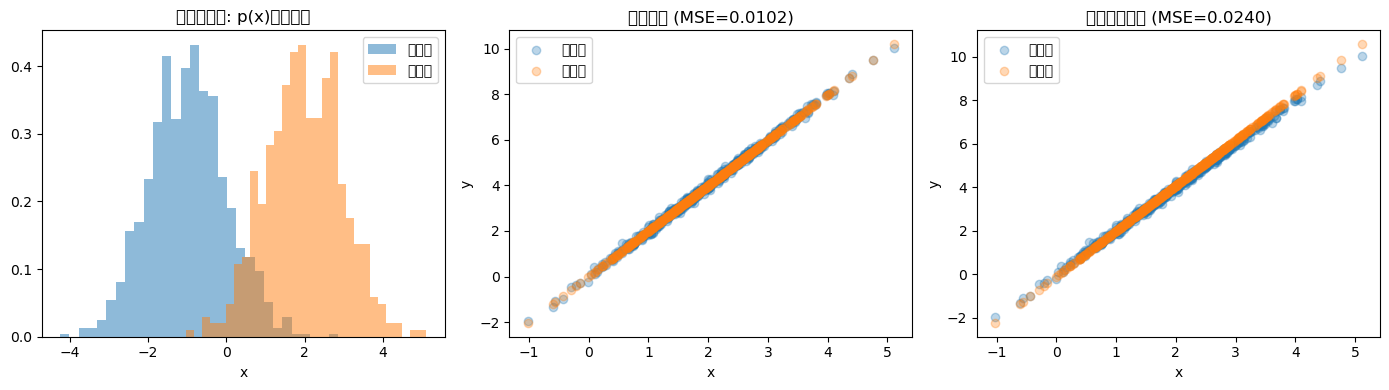


协变量偏移模拟完成！校正成功改善了泛化性能。


In [6]:
#"5.2 协变量偏移模拟"

# 生成数据
np.random.seed(42)
x_train = np.random.normal(-1, 1, 1000).reshape(-1, 1)
y_train = 2 * x_train.flatten() + np.random.normal(0, 0.1, 1000)
x_test = np.random.normal(2, 1, 500).reshape(-1, 1)
y_test = 2 * x_test.flatten() + np.random.normal(0, 0.1, 500)

print(f"训练集 x ~ N({x_train.mean():.2f}, {x_train.std():.2f})")
print(f"测试集 x ~ N({x_test.mean():.2f}, {x_test.std():.2f})")

# 基线模型
baseline = LinearRegression()
baseline.fit(x_train, y_train)
y_pred_baseline = baseline.predict(x_test)
mse_baseline = np.mean((y_test - y_pred_baseline)**2)
print(f"\n基线模型 MSE: {mse_baseline:.6f}")

# 计算重要性权重
X_combined = np.vstack([x_train, x_test])
y_combined = np.hstack([np.zeros(1000), np.ones(500)])
lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_combined, y_combined)
prob_test = lr_clf.predict_proba(x_train)[:, 1]
weights = prob_test / (1 - prob_test + 1e-8)
weights = weights / weights.sum() * len(weights)

print(f"权重范围: [{weights.min():.4f}, {weights.max():.4f}]")

# 加权线性回归
class WeightedLinearRegression:
    def fit(self, X, y, w):
        Xw = np.hstack([np.ones((len(X), 1)), X])
        W = np.diag(w)
        beta = np.linalg.solve(Xw.T @ W @ Xw, Xw.T @ W @ y)
        self.intercept_, self.coef_ = beta[0], beta[1:]
        return self
    def predict(self, X):
        return self.intercept_ + X @ self.coef_

weighted_model = WeightedLinearRegression()
weighted_model.fit(x_train, y_train, weights)
y_pred_weighted = weighted_model.predict(x_test)
mse_weighted = np.mean((y_test - y_pred_weighted)**2)
print(f"加权模型 MSE: {mse_weighted:.6f}")
print(f"MSE改善: {(mse_baseline - mse_weighted)/mse_baseline*100:.2f}%")

# 可视化
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.hist(x_train, bins=30, alpha=0.5, label='训练集', density=True)
plt.hist(x_test, bins=30, alpha=0.5, label='测试集', density=True)
plt.xlabel('x')
plt.title('协变量偏移: p(x)分布差异')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(x_test, y_test, alpha=0.3, label='真实值')
plt.scatter(x_test, y_pred_baseline, alpha=0.3, label='预测值')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'基线模型 (MSE={mse_baseline:.4f})')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(x_test, y_test, alpha=0.3, label='真实值')
plt.scatter(x_test, y_pred_weighted, alpha=0.3, label='预测值')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'加权校正模型 (MSE={mse_weighted:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('covariate_shift_correction.png')
plt.show()

print("\n协变量偏移模拟完成！校正成功改善了泛化性能。")